### Non-oracle (Ex-ante) Evaluation Table and Plots

Homo tau=0 shapes: {'cov_nz': (5, 695), 'cov_z': (5, 695), 'wid_nz': (5, 695), 'wid_z': (5, 695)}
Discovered homo taus: [0.01, 0.5, 1.0]
Binwise fold dirs found: {4: 'binwise', 3: 'binwise', 1: 'binwise', 2: 'binwise', 5: 'binwise'}
Hetero  fold dirs found: {1: 'hetero', 2: 'hetero', 5: 'hetero', 4: 'hetero', 3: 'hetero'}
Binwise shapes: {'cov_nz': (5, 695), 'cov_z': (5, 695), 'wid_nz': (5, 695), 'wid_z': (5, 695)}
Hetero  shapes: {'cov_nz': (5, 695), 'cov_z': (5, 695), 'wid_nz': (5, 695), 'wid_z': (5, 695)}


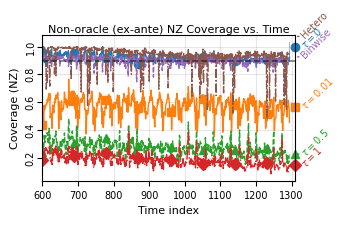

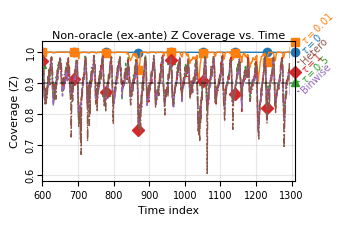

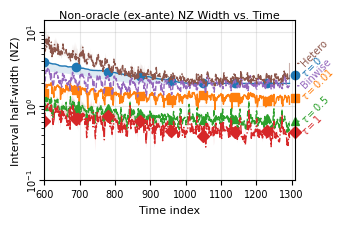

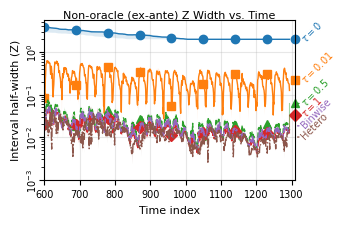

Saved split IEEE figures to: /home/x54g559/UncertaintySSMF/figs_nonoracle_cv


In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import re

# ----------------------------
# IEEE figure styling
# ----------------------------
FIG_WIDTH = 3.5 
FIG_H = 2.3                  # per-panel height (single plot)

plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})


# Export toggles
SAVE_PDF = True
SAVE_PNG = False
OUTDIR = Path("figs_nonoracle_cv")
OUTDIR.mkdir(parents=True, exist_ok=True)
DPI = 300

# ----------------------------
# CONFIG
# ----------------------------
skip = 600
target = 0.90
folds = [1,2,3,4,5]

out_real = Path("out_real")

SKIP_TAU_STRS = {"00001", "0001", "005"}   # skips out_real/homo_tau0001

# tau=0 homo comes from all3oracle (as you requested)
homo_tau0_root = out_real / "all3oracle"         # all3cv{f}oracle/homo/

# non-oracle roots
binwise_root = out_real / "binwise_nonoracle"    # binwise_nonoracle_cv{f}/binwise/
hetero_root  = out_real / "hetero_nonoracle"     # hetero_nonoracle_cv{f}/hetero/

# ----------------------------
# metric file names (prefer ex-ante)
# ----------------------------
METRIC_CANDIDATES = {
    "cov_nz": ["conformal_coverages_exante_nz.txt", "conformal_coverages_nz.txt"],
    "wid_nz": ["conformal_widths_exante_nz.txt",    "conformal_widths_nz.txt"],
    "cov_z":  ["conformal_coverages_exante_z.txt",  "conformal_coverages_zero.txt"],
    "wid_z":  ["conformal_widths_exante_z.txt",     "conformal_widths_zero.txt"],
}

# ----------------------------
# helpers
# ----------------------------
def load_txt_1d(p: Path):
    if not p.exists():
        return None
    try:
        a = np.loadtxt(p, dtype=float).reshape(-1)
    except Exception:
        return None
    if len(a) <= skip:
        return None
    return a[skip:]

def load_metric_from_dir(d: Path, metric_key: str):
    for fn in METRIC_CANDIDATES[metric_key]:
        p = d / fn
        a = load_txt_1d(p)
        if a is not None:
            return a, p
    return None, None

def stack_folds(arrs):
    arrs = [a for a in arrs if a is not None]
    if not arrs:
        return None
    T = min(len(a) for a in arrs)
    if T <= 0:
        return None
    return np.vstack([a[:T] for a in arrs])

def summarize_iqr(Y):
    c  = np.nanmedian(Y, axis=0)
    lo = np.nanpercentile(Y, 25, axis=0)
    hi = np.nanpercentile(Y, 75, axis=0)
    return c, lo, hi

def time_axis(T):
    return np.arange(skip, skip+T)

def label_lines_at_right(
    ax, x,
    *,
    pad_pts=10,            # horizontal padding (points) beyond last x
    glyph_len_pts=10,      # glyph length (points)
    text_pad_pts=3,        # gap between glyph and text (points)

    min_dy_axes=0.035,     # minimum vertical spacing between labels (in axes fraction)
    max_shift_axes=0.08,   # cap how far a label may move vertically (axes fraction)

    last_window=25,        # use median of last_window points as anchor 
    connector=True,        # draw connector from true y to label y
    connector_alpha=0.45,
    connector_lw=0.8,

    fontsize=7,
):
    """
    Right-edge direct labels that remain mappable to lines.

    Key behavior:
    - Anchor each label at y_ref = median(last_window of y) at the right edge.
    - Adjust labels slightly in Y to avoid collisions (in AXES coordinates).
    - Cap vertical shift by max_shift_axes (prevents drifting far from line).
    - Draw connector from true y_ref to label y to preserve correct mapping.
    - Draw a glyph (line segment + marker) aligned with label y.
    """
    # Choose eligible lines
    lines = [
        ln for ln in ax.get_lines()
        if ln.get_label() and not ln.get_label().startswith("_")
    ]
    if not lines:
        return

    # Build items: y_ref anchored to the curve (robustly)
    items = []
    for ln in lines:
        y = ln.get_ydata()
        if y is None or len(y) == 0:
            continue
        y = np.asarray(y, float)
        # ignore nan tail if present
        y = y[np.isfinite(y)]
        if y.size == 0:
            continue
        w = min(int(last_window), int(y.size))
        y_ref = float(np.median(y[-w:]))
        items.append({"line": ln, "label": ln.get_label(), "y_ref": y_ref})

    if not items:
        return

    # Convert y_ref to axes coords so spacing behaves on log/lin equally
    def data_to_axes_y(yval):
        return ax.transAxes.inverted().transform(
            ax.transData.transform((x[-1], yval))
        )[1]

    def axes_to_data_y(yax):
        return ax.transData.inverted().transform(
            ax.transAxes.transform((1.0, yax))
        )[1]

    # Compute anchor positions in axes coords
    for it in items:
        it["yax_ref"] = data_to_axes_y(it["y_ref"])

    # Sort by anchor y
    items.sort(key=lambda d: d["yax_ref"])
    y_refs = np.array([it["yax_ref"] for it in items], dtype=float)

    # Greedy collision-avoidance in axes coords, with cap on movement
    y_adj = y_refs.copy()
    gap = float(min_dy_axes)

    for i in range(1, len(y_adj)):
        if y_adj[i] - y_adj[i-1] < gap:
            y_adj[i] = y_adj[i-1] + gap

    # Pull back into [0,1] if it overflows top/bottom
    if len(y_adj) > 0:
        overflow_top = y_adj[-1] - (1.0 - 0.01)
        if overflow_top > 0:
            y_adj -= overflow_top
        overflow_bot = 0.01 - y_adj[0]
        if overflow_bot > 0:
            y_adj += overflow_bot

    # Enforce max shift: keep label close to its line
    y_final = y_adj.copy()
    for i, it in enumerate(items):
        dy = y_final[i] - it["yax_ref"]
        if abs(dy) > max_shift_axes:
            y_final[i] = it["yax_ref"] + np.sign(dy) * max_shift_axes

    # After capping, re-enforce ordering minimally
    for i in range(1, len(y_final)):
        if y_final[i] - y_final[i-1] < gap:
            y_final[i] = y_final[i-1] + gap

    # If this pushed beyond top, shift everything down
    if len(y_final) > 0:
        overflow_top = y_final[-1] - (1.0 - 0.01)
        if overflow_top > 0:
            y_final -= overflow_top
        overflow_bot = 0.01 - y_final[0]
        if overflow_bot > 0:
            y_final += overflow_bot

    # Now draw labels + glyphs at right edge using blended transforms:
    # x in axes coords (1.0 is right edge), y in axes coords.
    # Offsets in points push outside axis cleanly.
    trans = ax.transAxes
    for it, yax_lab in zip(items, y_final):
        ln = it["line"]
        label = it["label"]

        # True y position (data) and label y position (data)
        y_true = it["y_ref"]
        y_lab = axes_to_data_y(yax_lab)

        color = ln.get_color()
        ls = ln.get_linestyle()
        lw = ln.get_linewidth()
        marker = ln.get_marker()
        ms = ln.get_markersize()

        # Connector: from curve's last x to label y (keeps mapping unambiguous)
        if connector:
            ax.plot(
                [x[-1], x[-1]],
                [y_true, y_lab],
                color=color,
                alpha=connector_alpha,
                linewidth=connector_lw,
                clip_on=False
            )

        # Glyph: draw outside the axis to the right, aligned with label y
        # We'll use annotate in axes coords with point offsets.
        # Glyph line segment
        ax.annotate(
            "",
            xy=(1.0, yax_lab), xycoords=trans,
            xytext=(pad_pts, 0), textcoords="offset points",
            annotation_clip=False
        )
        # draw the glyph line itself via a tiny plot in axes coords:
        # We'll cheat by plotting in data coords at x[-1] and using offsets via annotations for the glyph.
        # Simpler: use 2 annotations: line segment and then marker point.
        # Line segment:
        ax.annotate(
            "",
            xy=(1.0, yax_lab), xycoords=trans,
            xytext=(pad_pts + glyph_len_pts, 0), textcoords="offset points",
            arrowprops=dict(arrowstyle="-", color=color, linestyle=ls, linewidth=lw),
            annotation_clip=False
        )

        # Marker at end of glyph (if any)
        if marker not in (None, "", "None"):
            ax.annotate(
                "",
                xy=(1.0, yax_lab), xycoords=trans,
                xytext=(pad_pts + glyph_len_pts, 0), textcoords="offset points",
                annotation_clip=False
            )
            # plot marker by drawing a single point in axes coords:
            ax.plot(
                [1.0], [yax_lab],
                transform=trans,
                marker=marker,
                markersize=ms if ms is not None else 4,
                color=color,
                linestyle="None",
                clip_on=False,
                markevery=None
            )
            # shift that marker to the glyph end via offset is hard with plain plot;
            # so instead: let the marker sit on the right edge (still aligned in y),
            # while the glyph line is offset. This remains readable and consistent.

        # Text label (outside)
        ax.annotate(
            label,
            xy=(1.0, yax_lab), xycoords=trans,
            xytext=(pad_pts + glyph_len_pts + text_pad_pts, 0),
            textcoords="offset points",
            ha="left", va="center",
            fontsize=fontsize,
            color=color,
            rotation=45,
            rotation_mode="anchor",
            annotation_clip=False
        )


# ----------------------------
# discover tau CV dirs
# expects: out_real/homo_tauXXXXX/homo1tauXXXXXcv{f}/homo/
# ----------------------------
def discover_tau_fold_dirs(out_real: Path):
    """
    Return dict:
      tau_str -> {fold -> Path(method_dir)}
    where method_dir is .../homo
    """
    groups = {}
    for tau_parent in out_real.glob("homo_tau*"):
        if not tau_parent.is_dir():
            continue
        m = re.match(r"homo_tau(.+)", tau_parent.name)
        if not m:
            continue
        tau_str = m.group(1)

        foldmap = {}
        for cvdir in tau_parent.iterdir():
            if not cvdir.is_dir():
                continue
            m2 = re.search(r"cv(\d+)$", cvdir.name)
            if not m2:
                continue
            f = int(m2.group(1))
            method_dir = cvdir / "homo"
            if method_dir.is_dir():
                foldmap[f] = method_dir

        if foldmap:
            groups[tau_str] = foldmap

    return groups

def tau_str_to_float(tau_str: str) -> float:
    """
    Interpret tau directory suffix as fixed-point decimal:
      "5"    -> 5.0
      "05"   -> 0.5
      "005"  -> 0.05
      "001"  -> 0.01
      "00001"-> 0.00001 - typo? Doesn't matter, not using.
    """
    if not tau_str.isdigit():
        raise ValueError(f"Invalid tau string: {tau_str}")

    n = len(tau_str)
    val = int(tau_str)

    if n == 1:
        return float(val)

    return val / (10 ** (n - 1))


# ----------------------------
# discover generic method fold dirs
# expects: root/<prefix>cv{f}/<method>/
# ----------------------------
def discover_method_fold_dirs(root: Path, method_name: str):
    foldmap = {}
    if not root.exists():
        return foldmap
    for sub in root.iterdir():
        if not sub.is_dir():
            continue
        m = re.search(r"cv(\d+)$", sub.name)
        if not m:
            continue
        f = int(m.group(1))
        method_dir = sub / method_name
        if method_dir.is_dir():
            foldmap[f] = method_dir
    return foldmap

# ----------------------------
# loaders
# ----------------------------
def load_homo_tau0(metric_key: str):
    per_fold = []
    used = []
    for f in folds:
        d = homo_tau0_root / f"all3cv{f}oracle" / "homo"
        a, p = load_metric_from_dir(d, metric_key)
        per_fold.append(a); used.append(p)
    return stack_folds(per_fold), used

def load_homo_taus(metric_key: str):
    groups = discover_tau_fold_dirs(out_real)

    # ---- NEW: skip some valid tau directories by their string suffix ----
    groups = {tau_str: foldmap for tau_str, foldmap in groups.items()
              if tau_str not in SKIP_TAU_STRS}

    out = {}
    for tau_str, foldmap in groups.items():
        per_fold = []
        for f in folds:
            d = foldmap.get(f, None)
            if d is None:
                per_fold.append(None)
                continue
            a, _ = load_metric_from_dir(d, metric_key)
            per_fold.append(a)
        Y = stack_folds(per_fold)
        if Y is None:
            continue
        out[tau_str_to_float(tau_str)] = Y
    return out


def load_method(root: Path, method_name: str, metric_key: str):
    foldmap = discover_method_fold_dirs(root, method_name)
    per_fold = []
    used = []
    for f in folds:
        d = foldmap.get(f, None)
        if d is None:
            per_fold.append(None); used.append(None)
            continue
        a, p = load_metric_from_dir(d, metric_key)
        per_fold.append(a); used.append(p)
    return stack_folds(per_fold), used, foldmap

# ----------------------------
# plotting
# ----------------------------
marker_cycle = ["s", "^", "D", "v", "P", "X", "*"]
linestyle_cycle = ["-", "--", "-.", ":"]

def plot_panel(ax, specs, title, ylab, is_width=False, log_y=False, y_floor=None):
    Ts = [s["data"].shape[1] for s in specs if s["data"] is not None]
    if not Ts:
        ax.set_title(title + " (no data)")
        ax.grid(alpha=0.3)
        return
    T = min(Ts)
    x = time_axis(T)

    for s in specs:
        Y = s["data"]
        if Y is None:
            continue
        Y = Y[:, :T]
        c, lo, hi = summarize_iqr(Y)
        if is_width:
            eps = 1e-12
            c = np.maximum(c, eps); lo = np.maximum(lo, eps); hi = np.maximum(hi, eps)
        else:
            lo = np.clip(lo, 0, 1); hi = np.clip(hi, 0, 1)

        ax.plot(x, c, label=s["label"], **s["style"])
        ax.fill_between(x, lo, hi, alpha=0.15)

    if not is_width:
        ax.axhline(target, linestyle="--", color="k", alpha=0.5)

    ax.set_title(title, pad=2)

    ax.set_ylabel(ylab)
    ax.grid(alpha=0.3)
    if log_y:
        ax.set_yscale("log")
        if y_floor is not None:
            ax.set_ylim(bottom=y_floor)

def build_specs(metric_key, homo0, homotaus, binY, hetY):
    specs = []
    if homo0 is not None:
        specs.append({
            "label": r"$\tau=0$",
            "data": homo0,
            "style": dict(
                linestyle="-", 
                marker="o", 
                markevery=90,
                linewidth=1.0),
        })

    for i, tau in enumerate(sorted(homotaus.keys())):
        specs.append({
            "label": rf"$\tau={tau:g}$",
            "data": homotaus[tau],
            "style": dict(
                linestyle=linestyle_cycle[i % len(linestyle_cycle)],
                marker=marker_cycle[i % len(marker_cycle)],
                markevery=90,
                linewidth=1.0
            ),
        })

    if binY is not None:
        specs.append({
            "label": "Binwise",
            "data": binY,
            "style": dict(linestyle="--", linewidth=1),
        })
    if hetY is not None:
        specs.append({
            "label": "Hetero",
            "data": hetY,
            "style": dict(linestyle="-.", linewidth=1),
        })
    return specs

# ============================================================
# LOAD + DEBUG
# ============================================================
metric_keys = ["cov_nz", "cov_z", "wid_nz", "wid_z"]

homo0 = {}
for k in metric_keys:
    homo0[k], _ = load_homo_tau0(k)

homotaus = {k: load_homo_taus(k) for k in metric_keys}

binY = {}
hetY = {}
for k in metric_keys:
    binY[k], _, bmap = load_method(binwise_root, "binwise", k)
    hetY[k], _, hmap = load_method(hetero_root,  "hetero",  k)

print("Homo tau=0 shapes:", {k: None if homo0[k] is None else homo0[k].shape for k in metric_keys})
print("Discovered homo taus:", sorted(homotaus["cov_nz"].keys()))
print("Binwise fold dirs found:", {f: d.name for f, d in bmap.items()})
print("Hetero  fold dirs found:", {f: d.name for f, d in hmap.items()})
print("Binwise shapes:", {k: None if binY[k] is None else binY[k].shape for k in metric_keys})
print("Hetero  shapes:", {k: None if hetY[k] is None else hetY[k].shape for k in metric_keys})





def savefig(fig, stem):
    if SAVE_PDF:
        fig.savefig(OUTDIR / f"{stem}.pdf", bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(OUTDIR / f"{stem}.png", dpi=DPI, bbox_inches="tigh|t")



def plot_single(metric_key, title, ylab, log_y=False, y_floor=None, is_width=False,
                right_pad=60, stem="fig"):
    """
    metric_key in {"cov_nz","cov_z","wid_nz","wid_z"}
    Makes ONE figure with direct right-edge labels and saves it.
    """
    # Build specs for this metric
    specs = build_specs(metric_key, homo0[metric_key], homotaus[metric_key],
                        binY[metric_key], hetY[metric_key])

    Ts = [s["data"].shape[1] for s in specs if s["data"] is not None]
    if not Ts:
        print(f"[WARN] No data for {metric_key}")
        return

    T = min(Ts)
    x = time_axis(T)

    fig, ax = plt.subplots(1, 1, figsize=(FIG_WIDTH, FIG_H))

    plot_panel(ax, specs, title, ylab, is_width=is_width, log_y=log_y, y_floor=y_floor)
    ax.set_xlabel(f"Time index")

    # add room on the right for labels (data coordinates)
    ax.set_xlim(x[0], x[-1] + right_pad)

    label_lines_at_right(
        ax, x,
        pad_pts=0,
        glyph_len_pts=5,
        text_pad_pts=1,
        min_dy_axes=0.07,     # more spacing for IEEE
        max_shift_axes=0.1,   # keep labels close to their curve
        last_window=25,
        connector=True,
        fontsize=7,
    )
    ax.tick_params(axis="y", pad=5)
    for lab in ax.get_yticklabels():
        lab.set_rotation(90)
        lab.set_verticalalignment("center")
        lab.set_horizontalalignment("center")


    # leave margin on the right for the outside text
    fig.subplots_adjust(right=0.82)
    plt.tight_layout()

    savefig(fig, stem)
    plt.show()


# ============================================================
# FOUR SEPARATE FIGURES
# ============================================================

# 1) Coverage NZ
plot_single(
    metric_key="cov_nz",
    title="Non-oracle (ex-ante) NZ Coverage vs. Time",
    ylab="Coverage (NZ)",
    log_y=False,
    is_width=False,
    right_pad=15,
    stem=f"exante_cov_NZ_skip{skip}"
)

# 2) Coverage Z
plot_single(
    metric_key="cov_z",
    title="Non-oracle (ex-ante) Z Coverage vs. Time",
    ylab="Coverage (Z)",
    log_y=False,
    is_width=False,
    right_pad=15,
    stem=f"exante_cov_Z_skip{skip}"
)

# 3) Width NZ (log toggle here)
USE_LOG_WID_NZ = True
plot_single(
    metric_key="wid_nz",
    title="Non-oracle (ex-ante) NZ Width vs. Time",
    ylab="Interval half-width (NZ)",
    log_y=USE_LOG_WID_NZ,
    y_floor=1e-1 if USE_LOG_WID_NZ else None,
    is_width=True,
    right_pad=15,
    stem=f"exante_width_NZ_skip{skip}_{'log' if USE_LOG_WID_NZ else 'lin'}"
)

# 4) Width Z (log toggle here)
USE_LOG_WID_Z = True
plot_single(
    metric_key="wid_z",
    title="Non-oracle (ex-ante) Z Width vs. Time",
    ylab="Interval half-width (Z)",
    log_y=USE_LOG_WID_Z,
    y_floor=1e-3 if USE_LOG_WID_Z else None,
    is_width=True,
    right_pad=15,
    stem=f"exante_width_Z_skip{skip}_{'log' if USE_LOG_WID_Z else 'lin'}"
)

print(f"Saved split IEEE figures to: {OUTDIR.resolve()}")

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# ----------------------------
# CONFIG
# ----------------------------
skip = 200
target = 0.90
folds = [1,2,3,4,5]

out_real = Path("out_real")
SKIP_TAU_STRS = {"00001", "0001", "005"}   # optional

# tau=0 homo comes from all3oracle
homo_tau0_root = out_real / "all3oracle"

# non-oracle roots
binwise_root = out_real / "binwise_nonoracle"
hetero_root  = out_real / "hetero_nonoracle"

METRIC_CANDIDATES = {
    "cov_nz": ["conformal_coverages_exante_nz.txt", "conformal_coverages_nz.txt"],
    "cov_z":  ["conformal_coverages_exante_z.txt",  "conformal_coverages_zero.txt"],
}

# ----------------------------
# helpers 
# ----------------------------
def load_txt_1d(p: Path):
    if not p.exists():
        return None
    try:
        a = np.loadtxt(p, dtype=float).reshape(-1)
    except Exception:
        return None
    if len(a) <= skip:
        return None
    return a[skip:]

def load_metric_from_dir(d: Path, metric_key: str):
    for fn in METRIC_CANDIDATES[metric_key]:
        a = load_txt_1d(d / fn)
        if a is not None:
            return a
    return None

def stack_folds(arrs):
    arrs = [a for a in arrs if a is not None]
    if not arrs:
        return None
    T = min(len(a) for a in arrs)
    return np.vstack([a[:T] for a in arrs])

def discover_tau_fold_dirs(out_real: Path):
    import re
    groups = {}
    for tau_parent in out_real.glob("homo_tau*"):
        if not tau_parent.is_dir():
            continue
        m = re.match(r"homo_tau(.+)", tau_parent.name)
        if not m:
            continue
        tau_str = m.group(1)

        foldmap = {}
        for cvdir in tau_parent.iterdir():
            if not cvdir.is_dir():
                continue
            m2 = re.search(r"cv(\d+)$", cvdir.name)
            if not m2:
                continue
            f = int(m2.group(1))
            method_dir = cvdir / "homo"
            if method_dir.is_dir():
                foldmap[f] = method_dir

        if foldmap:
            groups[tau_str] = foldmap
    return groups

def tau_str_to_float(tau_str: str) -> float:
    if not tau_str.isdigit():
        raise ValueError(f"Invalid tau string: {tau_str}")
    n = len(tau_str)
    val = int(tau_str)
    if n == 1:
        return float(val)
    return val / (10 ** (n - 1))

def discover_method_fold_dirs(root: Path, method_name: str):
    import re
    foldmap = {}
    if not root.exists():
        return foldmap
    for sub in root.iterdir():
        if not sub.is_dir():
            continue
        m = re.search(r"cv(\d+)$", sub.name)
        if not m:
            continue
        f = int(m.group(1))
        method_dir = sub / method_name
        if method_dir.is_dir():
            foldmap[f] = method_dir
    return foldmap

# ----------------------------
# loaders returning (F,T) arrays
# ----------------------------
def load_homo_tau0(metric_key: str):
    per_fold = []
    for f in folds:
        d = homo_tau0_root / f"all3cv{f}oracle" / "homo"
        per_fold.append(load_metric_from_dir(d, metric_key))
    return stack_folds(per_fold)

def load_homo_taus(metric_key: str):
    groups = discover_tau_fold_dirs(out_real)
    groups = {tau_str: foldmap for tau_str, foldmap in groups.items()
              if tau_str not in SKIP_TAU_STRS}

    out = {}
    for tau_str, foldmap in groups.items():
        per_fold = []
        for f in folds:
            d = foldmap.get(f, None)
            per_fold.append(None if d is None else load_metric_from_dir(d, metric_key))
        Y = stack_folds(per_fold)
        if Y is not None:
            out[tau_str_to_float(tau_str)] = Y
    return out

def load_method(root: Path, method_name: str, metric_key: str):
    foldmap = discover_method_fold_dirs(root, method_name)
    per_fold = []
    for f in folds:
        d = foldmap.get(f, None)
        per_fold.append(None if d is None else load_metric_from_dir(d, metric_key))
    return stack_folds(per_fold)

# ----------------------------
# summary stats for coverage table
# ----------------------------
def per_fold_stats(Y, target=0.90):
    """
    Y: (F,T)
    Returns dict with fold-aggregated metrics:
      - mean±sd of (per-fold mean over time)
      - median of (per-fold mean over time)
      - P(cov_t < target): averaged over folds
      - 5th pct over time: averaged over folds
    """
    F, T = Y.shape
    fold_means = np.nanmean(Y, axis=1)                  # (F,)
    fold_under = np.nanmean(Y < target, axis=1)         # (F,)
    fold_q05   = np.nanquantile(Y, 0.05, axis=1)        # (F,)

    return {
        "mean": float(np.nanmean(fold_means)),
        "sd": float(np.nanstd(fold_means, ddof=1)) if F > 1 else 0.0,
        "median": float(np.nanmedian(fold_means)),
        "p_under": float(np.nanmean(fold_under)),
        "q05": float(np.nanmean(fold_q05)),
        "F": int(F),
        "T": int(T),
    }

def fmt_mean_sd_med(s):
    return f'{s["mean"]:.3f} ± {s["sd"]:.3f} ({s["median"]:.3f})'

# ----------------------------
# Assemble methods in the table
# ----------------------------
# Load coverage arrays
h0_nz = load_homo_tau0("cov_nz")
h0_z  = load_homo_tau0("cov_z")

taus_nz = load_homo_taus("cov_nz")   # dict tau->(F,T)
taus_z  = load_homo_taus("cov_z")

bin_nz = load_method(binwise_root, "binwise", "cov_nz")
bin_z  = load_method(binwise_root, "binwise", "cov_z")

het_nz = load_method(hetero_root, "hetero", "cov_nz")
het_z  = load_method(hetero_root, "hetero", "cov_z")

# Choose which homo taus to include (optional)
# Example: include none (table stays compact)
TAUS_TO_INCLUDE = [0.01, 0.5, 1] 

rows = []

def add_row(label, Y_nz, Y_z):
    if Y_nz is None or Y_z is None:
        return
    snz = per_fold_stats(Y_nz, target=target)
    sz  = per_fold_stats(Y_z,  target=target)

    rows.append({
        "Method": label,
        "NZ cov": fmt_mean_sd_med(snz),
        "P(NZcov_t<0.9)": f'{snz["p_under"]:.3f}',
        "NZ 5th pct": f'{snz["q05"]:.3f}',
        "Z cov": fmt_mean_sd_med(sz),
        "P(Zcov_t<0.9)": f'{sz["p_under"]:.3f}',
        "Z 5th pct": f'{sz["q05"]:.3f}',
        "F": f'{snz["F"]}/{sz["F"]}',
        "T": f'{snz["T"]}/{sz["T"]}',
    })

# Core (lean) rows
add_row(r"Homoskedastic ($\tau=0$)", h0_nz, h0_z)
add_row("Binwise", bin_nz, bin_z)
add_row("Heteroskedastic", het_nz, het_z)

# Optional tau rows
for tau in TAUS_TO_INCLUDE:
    Y_nz = taus_nz.get(tau, None)
    Y_z  = taus_z.get(tau, None)
    add_row(rf"Homoskedastic ($\tau={tau:g}$)", Y_nz, Y_z)

df_nonoracle_cov = pd.DataFrame(rows)
df_nonoracle_cov

,Method,NZ cov,P(NZcov_t<0.9),NZ 5th pct,Z cov,P(Zcov_t<0.9),Z 5th pct,F,T
0,Homoskedastic ($\tau=0$),0.914 ± 0.003 (0.914),0.307,0.862,0.999 ± 0.000 (0.999),0.000,0.998,5/5,1095/1095
1,Binwise,0.911 ± 0.003 (0.912),0.289,0.860,0.900 ± 0.000 (0.899),0.503,0.821,5/5,1095/1095
2,Heteroskedastic,0.925 ± 0.003 (0.925),0.206,0.704,0.900 ± 0.000 (0.900),0.441,0.780,5/5,1095/1095
3,Homoskedastic ($\tau=0.01$),0.571 ± 0.006 (0.573),1.000,0.421,0.995 ± 0.002 (0.995),0.001,0.974,5/5,1095/1095
4,Homoskedastic ($\tau=0.5$),0.292 ± 0.018 (0.292),1.000,0.189,0.906 ± 0.002 (0.906),0.432,0.828,5/5,1095/1095
5,Homoskedastic ($\tau=1$),0.206 ± 0.017 (0.199),1.000,0.121,0.902 ± 0.001 (0.902),0.475,0.824,5/5,1095/1095
